In [214]:
# 高活性突变探索
import json
import os
import logging
import numpy as np
import requests
from PIL import Image
import scipy.stats
import matplotlib.pyplot as plt
import sys
import plotly.express as px
# pandas
import pandas as pd
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
# check环境
print(sys.executable)
print(sys.version)

/nfs_beijing/kubeflow-user/yujie/.conda/envs/icey/bin/python
3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]


In [215]:
def lib_mutation_distribution(df, title, density=True, exlist=[]):
    out = {}
    for mut in df['pdb_mutation'].to_list():
        if mut == '':
            continue
        mut = mut.split(',')

        for m in mut:
            if m in exlist:
                continue
            posi = int(m[2:-1])
            if posi not in out:
                out[posi] = {}
            if m[-1] not in out[posi]:
                out[posi][m[-1]] = 0
            out[posi][m[-1]] += 1
    # 创建热力图
    mut_df = pd.DataFrame(out).sort_index().fillna(0).T
    if density:
        mut_df = mut_df.div(mut_df.sum(axis=1), axis=0)
    mut_df = mut_df.sort_index()
    fig, ax = plt.subplots(figsize=(10, 10 * (mut_df.shape[0] / mut_df.shape[1])), dpi=200)
    im = ax.imshow(mut_df, cmap='YlOrRd')

    # 添加颜色条
    cbar = ax.figure.colorbar(im, ax=ax)
    # 添加标题和坐标轴标签
    ax.set_title(f'Distribution of mutations: {title}')
    ax.set_ylabel('Amino Acid Position')
    ax.set_xlabel('Amino Acid')

    # 设置坐标轴刻度标签
    ax.set_xticks(np.arange(len(mut_df.columns)))
    ax.set_yticks(np.arange(len(mut_df.index)))
    ax.set_xticklabels(mut_df.columns)
    ax.set_yticklabels(mut_df.index)
    # 显示图形
    plt.show()

## 获取MOO推荐数据

In [216]:
data = pd.read_csv('../data/data_ai_r2_all_scaned.csv')
print(data.shape)

(9153, 28)


## Base Filter

In [217]:
filter_config = {
    'sequence_naturalness': '`sequence_naturalness` < 3.6', 
    'stability': 'stability > -0.4',
    'structure_naturalness': 'structure_naturalness > -10.32',
    'activity_v1_seed1': 'activity_v1_seed1 > 2' ,
    'activity_v1_seed2': 'activity_v1_seed2 > 2.5' 
}
# 联合过滤漏斗
data_need_stru = data.copy(deep=True)
for score, query in filter_config.items():
    data_need_stru = data_need_stru.query(query)
    print(score, query, round(data_need_stru.shape[0]/data.shape[0], 3))
data_need_stru.shape

sequence_naturalness `sequence_naturalness` < 3.6 1.0
stability stability > -0.4 0.916
structure_naturalness structure_naturalness > -10.32 0.391
activity_v1_seed1 activity_v1_seed1 > 2 0.069
activity_v1_seed2 activity_v1_seed2 > 2.5 0.006


(56, 28)

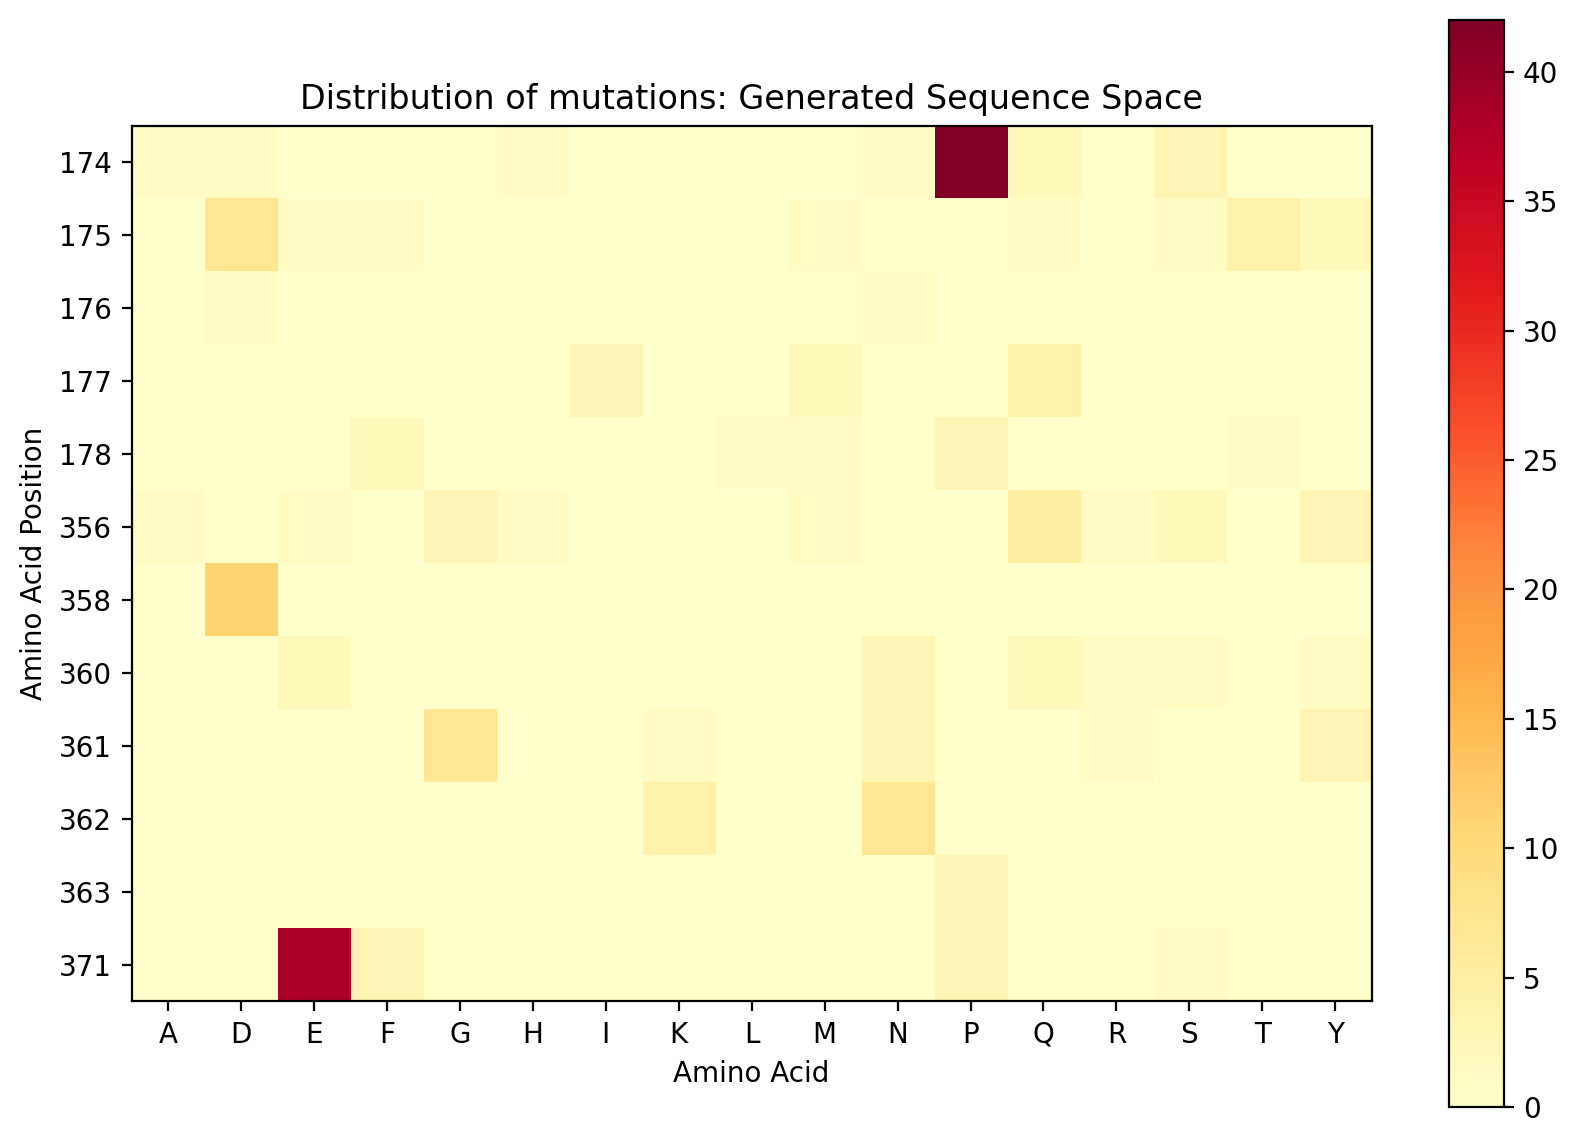

In [218]:
lib_mutation_distribution(data_need_stru, title='Generated Sequence Space', density=False)

In [219]:
data_need_stru.to_csv('../data/candidates_ai_round2.csv')